In [8]:
import torch
from torch import nn # for neural networks
import matplotlib.pyplot as plt

#Check PyTorch Version
torch.__version__


'2.10.0+cu128'

In [9]:
# Data (preparing and loading)

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [10]:
len(X), len(y)

(50, 50)

In [11]:
# Splitting data into training, valitaion, test set

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [12]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10,7))

#plot
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", label="Predictions")

  #Show legend
  plt.legend(prop={"size": 14});



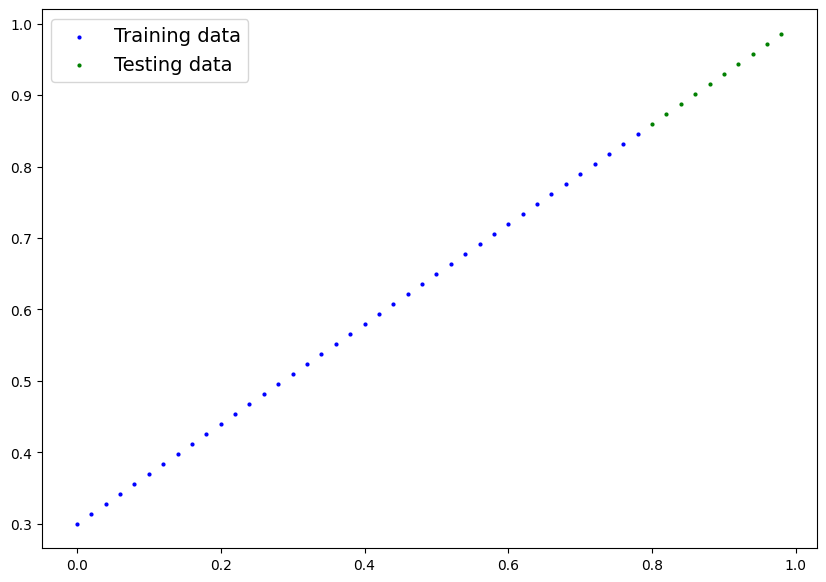

In [13]:
plot_predictions();

In [14]:
# Build Model
from torch import nn


class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  # Forward MEthod
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias


In [15]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [17]:
## Making Predictions using torch.inference_mode()

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [18]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

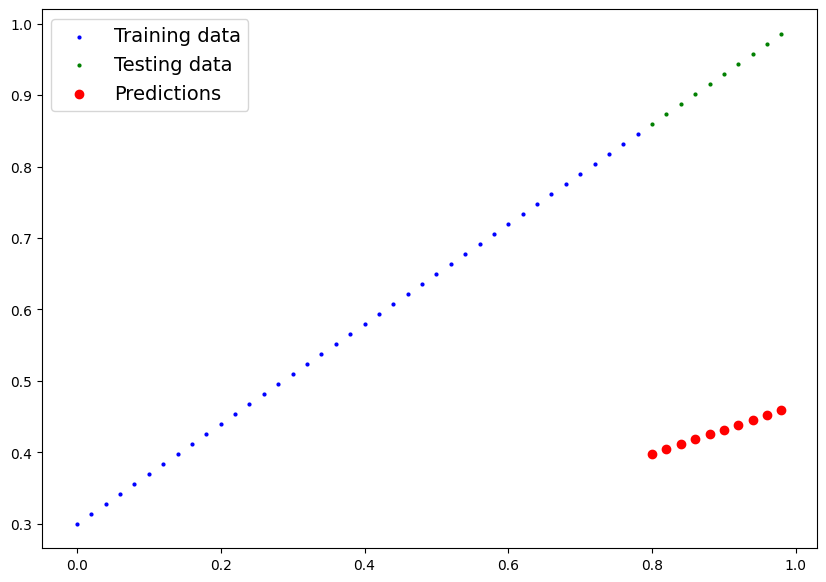

In [19]:
plot_predictions(predictions=y_preds)

In [20]:
# Train model, model will move from unknown parameters to known parameters.
# Loss Function Lower is better.
# Optimizer takes in loss and adjusts the model's parameters to improve the loss function (eg. weight & bias)
# a Training Loop and testing loop are needed

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [22]:
#Setup Loss Function

loss_fn = nn.L1Loss()


#Setup Optimizer

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)


In [23]:
# Building a training loop in Pytorch

# loop thru data
# Forward pass / propagation (data moves throw out the model)
# Calculate the loss
# Optimizer zero grad
# Loss backward - move backwaerds through the network to calcaluate the gradiensts of each of the paramater
#

epochs = 200

# track values
epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs):

  # Set model to training mode
  model_0.train() # train mode set

  # 1. Forward pass
  y_preds = model_0(X_train)

  # Calculate loss
  loss = loss_fn(y_preds,y_train)
  print(f"loss:,{loss}")

  # Optimizier
  optimizer.zero_grad()

  # backprogation
  loss.backward()

  # 👇 Inspect gradients here - Extra bit I added can be put in loop
  for name, param in model_0.named_parameters():
    if param.grad is not None:
      print(f"{name} grad:\n{param.grad}\n")

  # Step Optimizer
  optimizer.step()

# Testing

  model_0.eval() # turns off certain features for evaluation
  with torch.inference_mode():

    # Forward Pass
    test_pred = model_0(X_test)

    # Calculate Loss
    test_loss = loss_fn(test_pred, y_test)


  if epoch % 10 == 0:
    epoch_count.append(epoch)
    train_loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
    print(model_0.state_dict())

loss:,0.31288138031959534
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
loss:,0.3013603389263153
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.28983935713768005
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.2783183455467224
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.26679736375808716
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.2552763521671295
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.24375534057617188
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.23223432898521423
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.22071333229541779
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.20919232070446014
weights grad:
tensor([-0.3900])

bias grad:
tensor([-1.])

loss:,0.197671

In [24]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

model_0.state_dict()


OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [25]:
weight, bias

(0.7, 0.3)

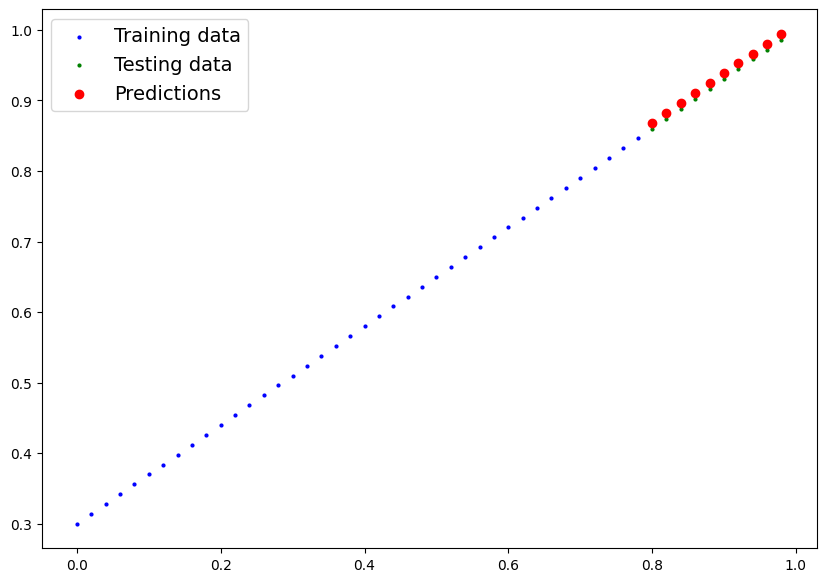

In [26]:
plot_predictions(predictions=y_preds_new);

/tmp/ipykernel_4193/1205366318.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(train_loss_values).numpy()), label="Train loss")


Text(0.5, 0, 'Epochs')

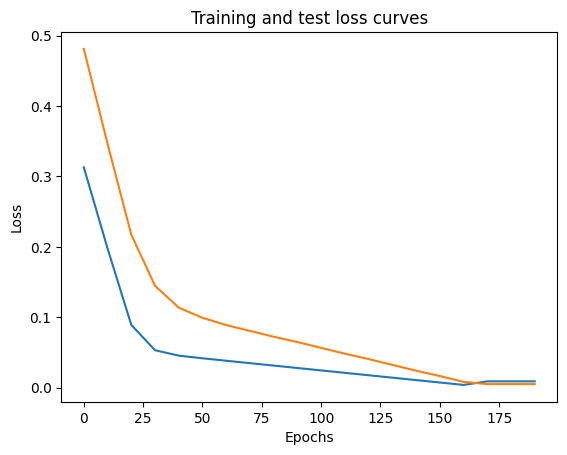

In [27]:
import numpy as np


# Plot loss curves

plt.plot(epoch_count, np.array(torch.tensor(train_loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")

In [28]:
# Saving and Loading models in Pytorch
# 3 main methods

#1 torch.save - saves in python pickle mehtood
#2 torch.load - allows you to load a saved Pytorch Object
#3 torch.nn.Module.load_state_dict() - allows to load a model's saved state dictionary

model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [29]:
#saving Model

from pathlib import Path
# Create Models Directory

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Model Save Pth

MODEL_NAME= "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

# Save the model state.dict

print(f"Saving Model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving Model to: models/01_pytorch_workflow_model_0.pth


In [30]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Mar 21 13:18 01_pytorch_workflow_model_0.pth


In [31]:
#Load Model
# will have to create new instance seeing we saved state.dict, we didn't save the whole model

# Instantiate nedw instance using model class

loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [32]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [33]:
from pickle import load
# Mkae some predictions with loaded model

loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [34]:
#compare

y_preds_new == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [35]:
# Putting it all together, going over steps above

import torch
from torch import nn
import matplotlib.pyplot as plt

#Check Version of Pytorch
torch.__version__


'2.10.0+cu128'

In [36]:
# Setup Device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [37]:
!nvidia-smi


Sat Mar 21 13:18:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [38]:
# Data linear regression

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]



(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [39]:
#split data

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

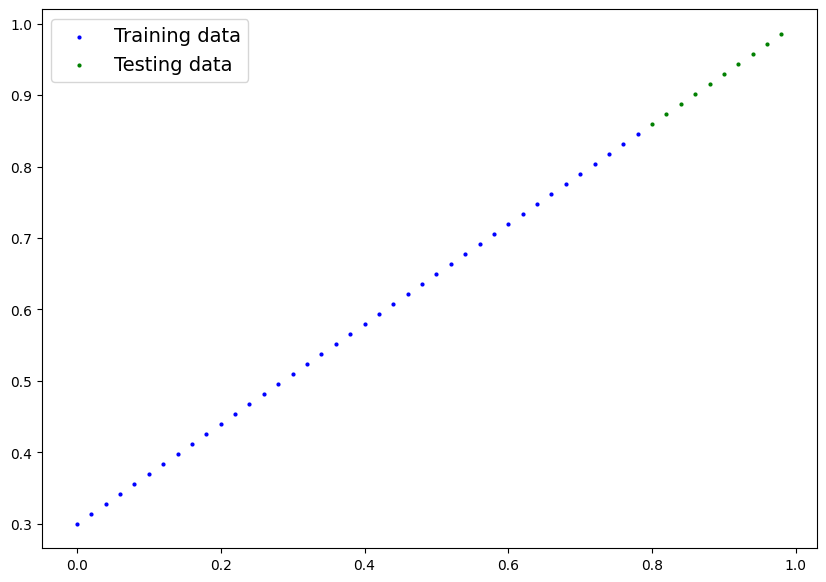

In [40]:
# Plot Data

plot_predictions(X_train, y_train,X_test, y_test)

In [45]:
# Build Pytorch Linaer Model by subclassing nn.Module

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating model parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.linear_layer(x)

# Set Manual Seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))